In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

In [56]:
df = pd.read_csv('data\california.csv')
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [57]:
df.shape

(20640, 10)

In [58]:
# 결측치를 랜덤하게 생성하기
df_missing = df.copy()  # 데이터 프레임의 복사본 만들기
missing_count = 20  # 만들 결측치 개수

# 랜덤결과를 동일하게 만들기 위한 랜덤 생성자 만들기
rng = np.random.default_rng(42)

rows = rng.integers(0, df.shape[0], size=missing_count)
cols = rng.integers(0, df.shape[1], size=missing_count)

print(rows)
print(cols)

[ 1842 15974 13510  9058  8937 17721  1773 14393  4158  1943 10866 20136
 15185 15709 14808 16224 10592  2644 17332  9295]
[5 3 1 9 7 6 4 8 5 4 4 2 0 5 8 0 8 8 2 6]


In [59]:
# 랜덤한 셀에 NaN을 대입

for i in range(missing_count):
    df_missing.iloc[rows[i], cols[i]] = np.nan
    
#

In [60]:
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20638 non-null  float64
 1   latitude            20639 non-null  float64
 2   housing_median_age  20638 non-null  float64
 3   total_rooms         20639 non-null  float64
 4   total_bedrooms      20430 non-null  float64
 5   population          20637 non-null  float64
 6   households          20638 non-null  float64
 7   median_income       20639 non-null  float64
 8   median_house_value  20636 non-null  float64
 9   ocean_proximity     20639 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [62]:
df_missing.isna()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False,False


In [63]:
# 각 컬럼들의 결측치 개수를 확인하기

df_missing.isna().sum()

longitude               2
latitude                1
housing_median_age      2
total_rooms             1
total_bedrooms        210
population              3
households              2
median_income           1
median_house_value      4
ocean_proximity         1
dtype: int64

In [64]:
# 전테 데이터의 결측치 개수
print(df_missing.isna().sum().sum())

227


In [65]:
s = pd.Series([False, False, False, False])
print(s.values.any())

False


In [66]:
# 전체 데이터에는 결측치가 존재한다는 것을 확인
df_missing.isnull().values.any()

np.True_

In [67]:
# 결측치가 포함된 행만 출력하기

cond = df_missing.isna().any(axis=1)
df_missing[cond]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


In [68]:
# 결측치들을 처리하는 방법

# 1. 결측치 버리기 (행 삭제하기)
df_missing_res = df_missing.dropna()
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20413 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20413 non-null  float64
 1   latitude            20413 non-null  float64
 2   housing_median_age  20413 non-null  float64
 3   total_rooms         20413 non-null  float64
 4   total_bedrooms      20413 non-null  float64
 5   population          20413 non-null  float64
 6   households          20413 non-null  float64
 7   median_income       20413 non-null  float64
 8   median_house_value  20413 non-null  float64
 9   ocean_proximity     20413 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [69]:
# 2. 결측치를 새로운 값으로 채우기
# 모든 결측치들을 0으로 만듦
df_missing_res = df_missing.fillna(0)
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [70]:
# 모든 결측치들의 값을 평균값으로 채우기
df_missing_res = df_missing.fillna(df_missing.mean())
df_missing_res.info()

TypeError: can only concatenate str (not "int") to str

In [ ]:
# 수치형 컬럼들만 별도로 추출하여 각 컬럼들의 평균으로 그 컬럼에 있는 결측치를 채움
df_missing_res = df_missing.copy()
df_numbers = df_missing.select_dtypes(include=['number'])   # 수치형 컬럼들로만 구성된 DataFrmame
cols = df_numbers.columns   # 위 DataFrame의 컬럼들만 리스트로 구성하기
for col in cols:    # 각 컬럼들마다ㅏ 결측치들을 해당 컬럼의 평균으로 채움
    df_missing_res[col] = df_missing[col].fillna(df_missing[col].mean())    
    
# median() 사용해도 괜찮음
# mode(): 최빈값 --> 배열로 나옴 (여러개의 값들이 공동 1등을 할 수 있기 때문에)
# mode()[0]으로 사용해야함
    
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
# 3. 앞뒤값으로 채우기
df_missing_res = df_missing.copy()

df_missing_res = df_missing.ffill()     # 앞 행의 값으로 채워줌
df_missing_res = df_missing.bfill()     # 뒤 행의 값으로 채워줌

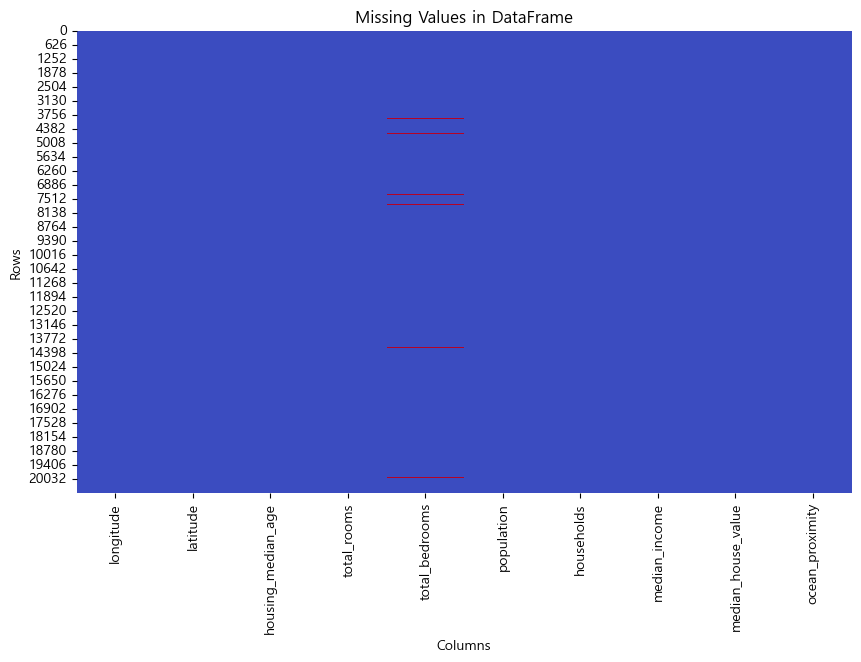

longitude               2
latitude                1
housing_median_age      2
total_rooms             1
total_bedrooms        210
population              3
households              2
median_income           1
median_house_value      4
ocean_proximity         1
dtype: int64

In [72]:
# 결측치를 한눈에 그래프로 보여주기
# 일반적으로 heatmap으로 보여줌

plt.figure(figsize=(10, 6))
sns.heatmap(df_missing.isna(), cbar=False, cmap='coolwarm')
plt.title('Missing Values in DataFrame')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

df_missing.isna().sum()